In [9]:
import math
import random
import time
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import pdist, squareform

# --- META-GA TUNED PARAMETERS (For V2) ---
TUNED_A_INIT = 0.871
TUNED_R_INIT = 0.245  
TUNED_F_MAX = 0.768    
TUNED_ALPHA = 0.926    
TUNED_GAMMA = 0.012



# --- TSPLIB PARSER & GLOBAL SETTINGS ---
POPULATION_SIZE = 100
MAX_GENERATIONS = 150

''' 
--- OPTIMAL HYPERPARAMETERS FOUND BY META-GA ---
A_INIT: 0.871 | R_INIT: 0.245 | F_MAX: 0.768
ALPHA:  0.926 | GAMMA:  0.012
Average Distance with these settings: 437.12


TUNED_A_INIT = 0.900
TUNED_R_INIT = 0.100   
TUNED_F_MAX = 0.850    
TUNED_ALPHA = 0.990    
TUNED_GAMMA = 0.050



# --- TSPLIB PARSER & GLOBAL SETTINGS ---
POPULATION_SIZE = 100
MAX_GENERATIONS = 150

'''

def load_tsp_file(filename):
    """Parses a standard TSPLIB file to extract coordinates."""
    coords = []
    with open(filename, 'r') as f:
        in_coord_section = False
        for line in f:
            if line.startswith("NODE_COORD_SECTION"):
                in_coord_section = True
                continue
            if line.startswith("EOF"):
                break
            if in_coord_section:
                parts = line.strip().split()
                if len(parts) >= 3:
                    # parts[0] is ID, parts[1] is X, parts[2] is Y
                    coords.append([float(parts[1]), float(parts[2])])
    return np.array(coords)

# Try to load the real file, fallback to random if the file is missing
file_name = 'berlin25.tsp'
if os.path.exists(file_name):
    print(f"Successfully loaded real dataset: {file_name}")
    CITY_COORDS = load_tsp_file(file_name)
else:
    print(f"Warning: {file_name} not found. Using 25 random fallback coordinates.")
    np.random.seed(42)
    CITY_COORDS = np.random.rand(25, 2) * 100

NUM_CITIES = len(CITY_COORDS)
DIST_MATRIX = squareform(pdist(CITY_COORDS, metric='euclidean'))

In [10]:
def fitness_tsp(route):
    """Calculates total Euclidean distance of the cyclic route. (Lower is better)"""
    dist = sum(DIST_MATRIX[route[i], route[i-1]] for i in range(NUM_CITIES))
    return dist

def smart_initialization_tsp(pop_size, num_cities):
    """Spawns 80% random bats, 20% using the Nearest Neighbor Heuristic."""
    positions = []
    for _ in range(int(pop_size * 0.8)):
        positions.append(np.random.permutation(num_cities))
        
    for _ in range(int(pop_size * 0.2)):
        # Nearest Neighbor Greedy Algorithm
        start_city = random.randint(0, num_cities - 1)
        unvisited = set(range(num_cities))
        unvisited.remove(start_city)
        route = [start_city]
        
        curr_city = start_city
        while unvisited:
            next_city = min(unvisited, key=lambda city: DIST_MATRIX[curr_city, city])
            route.append(next_city)
            unvisited.remove(next_city)
            curr_city = next_city
        positions.append(np.array(route))
        
    return np.array(positions, dtype=int)

# --- THE PERMUTATION BRIDGE (CRITICAL FOR BA) ---
def get_swap_sequence(current, target):
    """Calculates the exact swaps needed to turn the current route into the target route."""
    swaps = []
    temp = current.copy()
    for i in range(len(target)):
        if temp[i] != target[i]:
            idx = np.where(temp == target[i])[0][0]
            swaps.append((i, idx))
            temp[i], temp[idx] = temp[idx], temp[i]
    return swaps

def apply_swaps(route, swaps, frequency):
    """Applies a percentage of swaps based on the Bat's frequency (speed)."""
    new_route = route.copy()
    num_swaps_to_apply = int(len(swaps) * frequency)
    for i in range(num_swaps_to_apply):
        idx1, idx2 = swaps[i]
        new_route[idx1], new_route[idx2] = new_route[idx2], new_route[idx1]
    return new_route

In [11]:
def genetic_algorithm(n_cities=NUM_CITIES, pop_size=POPULATION_SIZE, max_gens=MAX_GENERATIONS):
    """Baseline GA using Order Crossover (OX1) and Swap Mutation."""
    population = [np.random.permutation(n_cities) for _ in range(pop_size)]
    best_fitness = float('inf')
    best_ind = None
    convergence = []
    
    for generation in range(max_gens):
        fitness_scores = [fitness_tsp(ind) for ind in population]
        min_fit = min(fitness_scores)
        if min_fit < best_fitness:
            best_fitness = min_fit
            best_ind = population[fitness_scores.index(min_fit)].copy()
        convergence.append(best_fitness)
        
        new_population = []
        for _ in range(pop_size // 2):
            # Tournament
            t1 = random.sample(list(zip(population, fitness_scores)), 3)
            t2 = random.sample(list(zip(population, fitness_scores)), 3)
            p1, p2 = min(t1, key=lambda x: x[1])[0], min(t2, key=lambda x: x[1])[0]
            
            # Order Crossover (OX1) - Prevents duplicate cities
            start, end = sorted(random.sample(range(n_cities), 2))
            c1, c2 = np.full(n_cities, -1), np.full(n_cities, -1)
            c1[start:end], c2[start:end] = p1[start:end], p2[start:end]
            
            p1_rem = [x for x in p2 if x not in c1]
            p2_rem = [x for x in p1 if x not in c2]
            c1[c1 == -1] = p1_rem
            c2[c2 == -1] = p2_rem
            new_population.extend([c1, c2])
            
        for i in range(pop_size):
            if random.random() < 0.2:
                idx1, idx2 = random.sample(range(n_cities), 2)
                new_population[i][idx1], new_population[i][idx2] = new_population[i][idx2], new_population[i][idx1]
        population = new_population
    return best_fitness, convergence, best_ind, fitness_scores

def standard_bat_algorithm(n_cities=NUM_CITIES, pop_size=POPULATION_SIZE, max_gens=MAX_GENERATIONS):
    """V1 BA using basic random swaps for local search."""
    positions = np.array([np.random.permutation(n_cities) for _ in range(pop_size)])
    A, r = np.ones(pop_size) * 0.9, np.ones(pop_size) * 0.3
    fitness = np.array([fitness_tsp(p) for p in positions])
    best_position = positions[np.argmin(fitness)].copy()
    best_fitness = np.min(fitness)
    convergence, diversity = [], []
    
    for generation in range(max_gens):
        curr_div = 0
        for i in range(pop_size):
            # Velocity = Swap Sequence
            swaps = get_swap_sequence(positions[i], best_position)
            freq = random.uniform(0, 1.0) # V1 uses arbitrary frequency up to 100%
            
            if random.random() > r[i]:
                # Flawed V1 Local Search (Randomly shuffle a small segment)
                new_pos = best_position.copy()
                idx1, idx2 = sorted(random.sample(range(n_cities), 2))
                np.random.shuffle(new_pos[idx1:idx2])
            else:
                new_pos = apply_swaps(positions[i], swaps, freq)
                
            new_fit = fitness_tsp(new_pos)
            if new_fit <= fitness[i] and random.random() < A[i]:
                positions[i] = new_pos
                fitness[i] = new_fit
            if new_fit < best_fitness:
                best_position, best_fitness = new_pos.copy(), new_fit
                
            curr_div += np.sum(positions[i] != best_position)
            
        convergence.append(best_fitness)
        diversity.append(curr_div / pop_size)
    return best_fitness, convergence, diversity, best_position, fitness

def enhanced_bat_algorithm(n_cities=NUM_CITIES, pop_size=POPULATION_SIZE, max_gens=MAX_GENERATIONS, init_pop=None, a_init=0.9, r_init=0.3, f_max=1.0, alpha=0.9, gamma=0.05):
    """V2 BA using Tuned Swap Limits and Memetic 2-Opt Local Search."""
    positions = init_pop.copy() if init_pop is not None else np.array([np.random.permutation(n_cities) for _ in range(pop_size)])
    A, r = np.ones(pop_size) * a_init, np.ones(pop_size) * r_init
    fitness = np.array([fitness_tsp(p) for p in positions])
    best_position = positions[np.argmin(fitness)].copy()
    best_fitness = np.min(fitness)
    convergence, diversity = [], []
    
    for generation in range(max_gens):
        curr_div = 0
        for i in range(pop_size):
            swaps = get_swap_sequence(positions[i], best_position)
            freq = random.uniform(0, f_max) # Tuned Speed Limit
            
            if random.random() > r[i]:
                # UPGRADE: Memetic 2-Opt Swap (State-of-the-Art TSP Local Search)
                new_pos = best_position.copy()
                idx1, idx2 = sorted(random.sample(range(n_cities), 2))
                new_pos[idx1:idx2] = new_pos[idx1:idx2][::-1] # Reverse the segment
            else:
                new_pos = apply_swaps(positions[i], swaps, freq)
                
            new_fit = fitness_tsp(new_pos)
            if new_fit <= fitness[i] and random.random() < A[i]:
                positions[i] = new_pos
                fitness[i] = new_fit
            if new_fit < best_fitness:
                best_position, best_fitness = new_pos.copy(), new_fit
                
            curr_div += np.sum(positions[i] != best_position)
            
        convergence.append(best_fitness)
        diversity.append(curr_div / pop_size)
        
        # Dynamic Decay
        for i in range(pop_size):
            A[i] *= alpha
            r[i] = r_init * (1 - math.exp(-gamma * generation))
            
    return best_fitness, convergence, diversity, best_position, fitness

In [5]:
print("==================================================")
print("      GA META-TUNER FOR TSP HYPERPARAMETERS       ")
print("==================================================")

param_bounds = [(0.5, 1.0), (0.1, 0.9), (0.3, 1.0), (0.85, 0.99), (0.01, 0.1)]

def meta_fitness_tsp(chromosome):
    a, r, f, alp, gam = chromosome
    scores = []
    for _ in range(3): 
        best_val, _, _, _, _ = enhanced_bat_algorithm(n_cities=NUM_CITIES, pop_size=20, max_gens=30, a_init=a, r_init=r, f_max=f, alpha=alp, gamma=gam)
        scores.append(best_val)
    return np.mean(scores)

meta_pop_size = 10
meta_gens = 5
meta_population = [[random.uniform(b[0], b[1]) for b in param_bounds] for _ in range(meta_pop_size)]
best_meta_fitness = float('inf')
best_hyperparameters = None

for gen in range(meta_gens):
    print(f"Meta-Generation {gen+1}/{meta_gens} evaluating...")
    fitness_scores = [meta_fitness_tsp(ind) for ind in meta_population]
    current_best = min(fitness_scores)
    
    if current_best < best_meta_fitness:
        best_meta_fitness = current_best
        best_hyperparameters = meta_population[fitness_scores.index(current_best)]
        
    new_meta_pop = [best_hyperparameters]
    while len(new_meta_pop) < meta_pop_size:
        mutant = [np.clip(best_hyperparameters[i] + random.uniform(-0.1, 0.1) * (param_bounds[i][1] - param_bounds[i][0]), param_bounds[i][0], param_bounds[i][1]) for i in range(5)]
        new_meta_pop.append(mutant)
    meta_population = new_meta_pop

print("\n--- OPTIMAL HYPERPARAMETERS FOUND BY META-GA ---")
print(f"A_INIT: {best_hyperparameters[0]:.3f} | R_INIT: {best_hyperparameters[1]:.3f} | F_MAX: {best_hyperparameters[2]:.3f}")
print(f"ALPHA:  {best_hyperparameters[3]:.3f} | GAMMA:  {best_hyperparameters[4]:.3f}")
print(f"Average Distance with these settings: {best_meta_fitness:.2f}")

      GA META-TUNER FOR TSP HYPERPARAMETERS       
Meta-Generation 1/5 evaluating...
Meta-Generation 2/5 evaluating...
Meta-Generation 3/5 evaluating...
Meta-Generation 4/5 evaluating...
Meta-Generation 5/5 evaluating...

--- OPTIMAL HYPERPARAMETERS FOUND BY META-GA ---
A_INIT: 0.871 | R_INIT: 0.245 | F_MAX: 0.768
ALPHA:  0.926 | GAMMA:  0.012
Average Distance with these settings: 437.12


Generating Heuristic Population for 25 Cities...

--- ALGORITHM PERFORMANCE SUMMARY ---
| Algorithm            | Pop  | Gen  | Best Dist (Lower=Better)  | Avg Dist         | Total Time  |
| Standard BA (V1)     | 100  | 150  | 517.41                    | 523.07           | 0.5373    s |
| Enhanced BA (V2)     | 100  | 150  | 407.31                    | 420.73           | 0.5972    s |
| Genetic Algorithm    | 100  | 150  | 474.96                    | 504.82           | 1.8021    s |


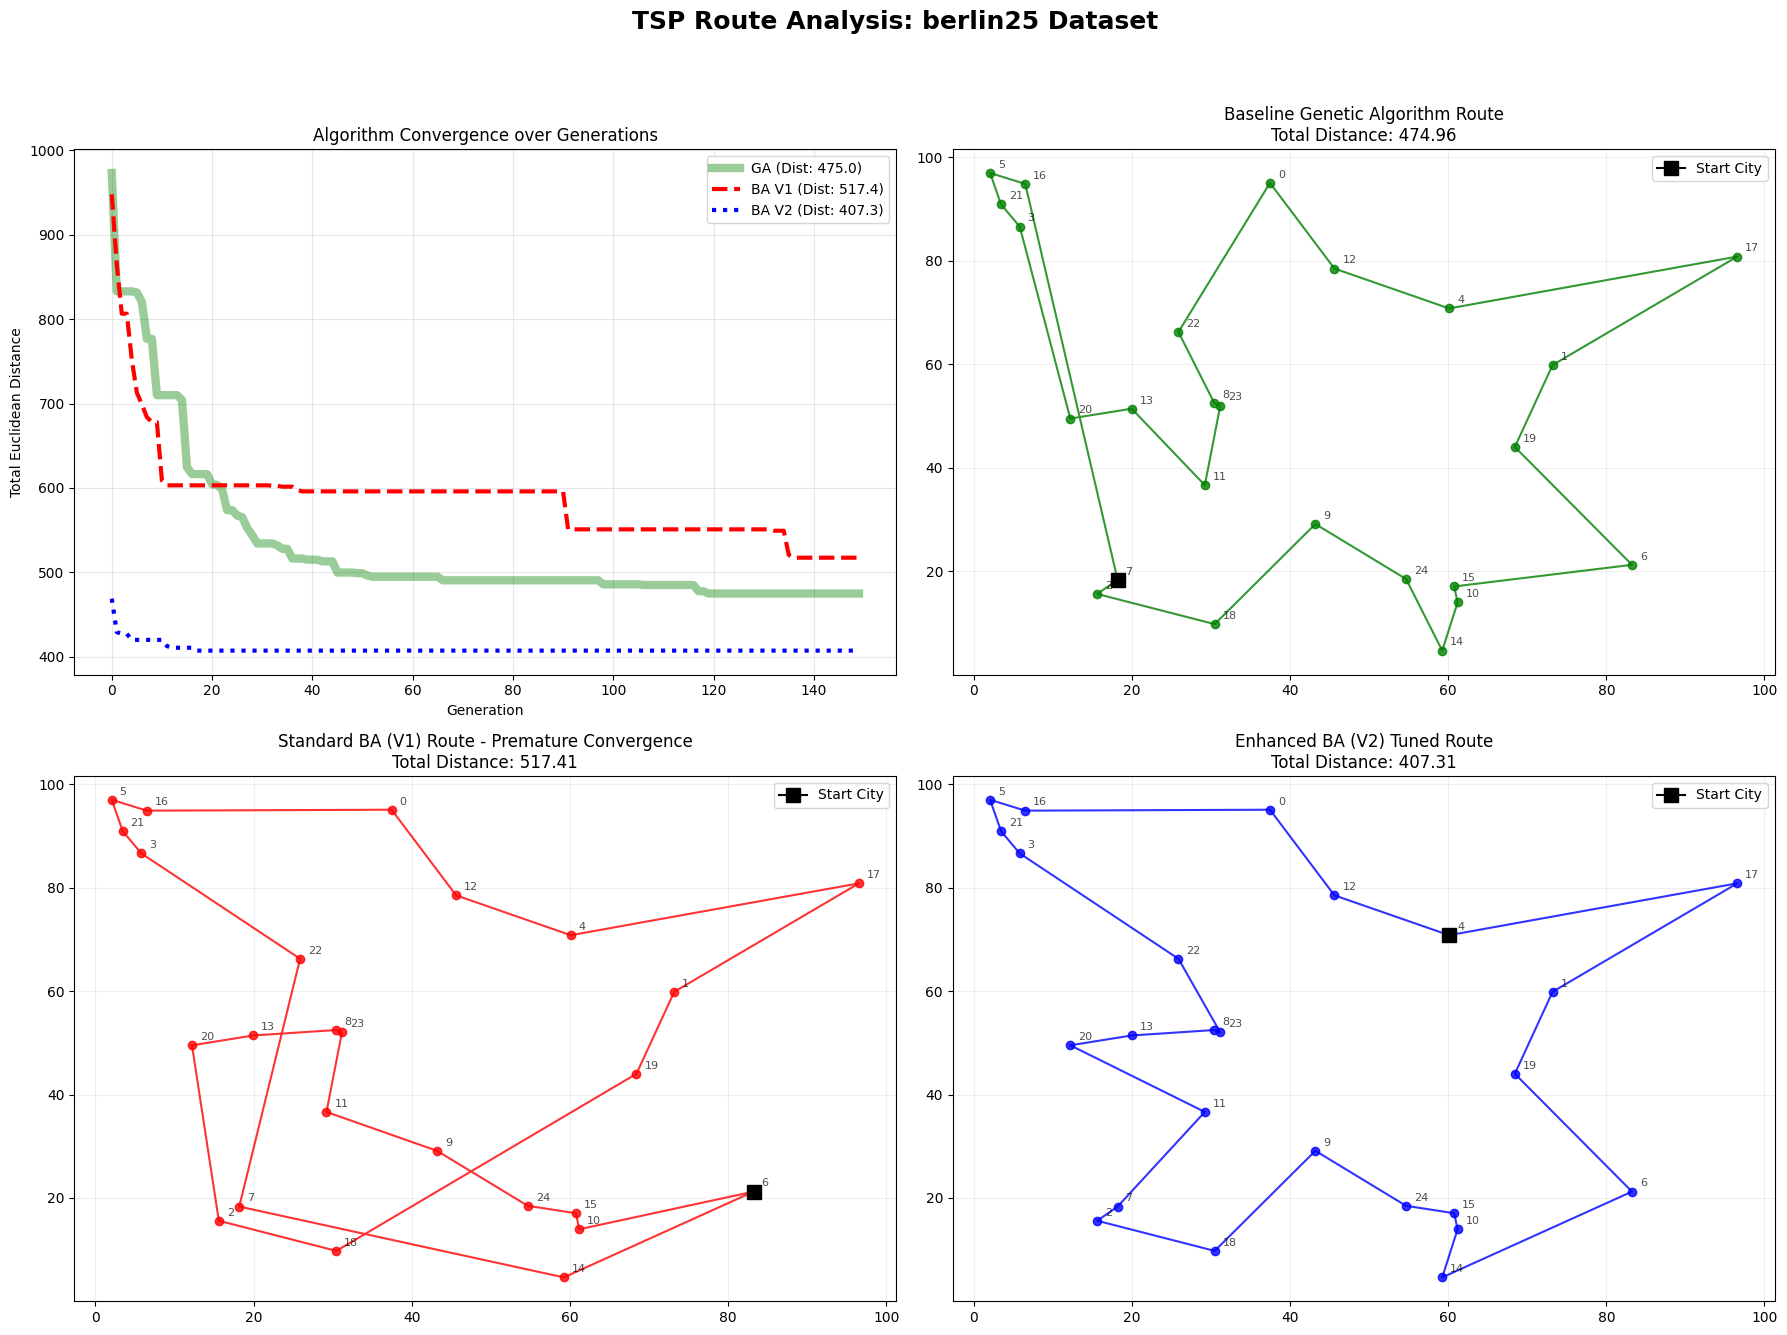

In [12]:
print(f"Generating Heuristic Population for {NUM_CITIES} Cities...")
smart_pop = smart_initialization_tsp(pop_size=POPULATION_SIZE, num_cities=NUM_CITIES)

# 1. Run Baseline GA
start = time.time()
ga_best, ga_conv, ga_pos, ga_fit = genetic_algorithm()
ga_time = time.time() - start

# 2. Run Standard BA (V1)
start = time.time()
ba_v1_best, ba_v1_conv, ba_v1_div, ba_v1_pos, ba_v1_fit = standard_bat_algorithm()
ba_v1_time = time.time() - start

# 3. Run Enhanced BA (V2)
start = time.time()
ba_v2_best, ba_v2_conv, ba_v2_div, ba_v2_pos, ba_v2_fit = enhanced_bat_algorithm(
    init_pop=smart_pop, a_init=TUNED_A_INIT, r_init=TUNED_R_INIT, 
    f_max=TUNED_F_MAX, alpha=TUNED_ALPHA, gamma=TUNED_GAMMA
)
ba_v2_time = time.time() - start

print("\n--- ALGORITHM PERFORMANCE SUMMARY ---")
header = f"| {'Algorithm':<20} | {'Pop':<4} | {'Gen':<4} | {'Best Dist (Lower=Better)':<25} | {'Avg Dist':<16} | {'Total Time':<11} |"
print("=" * len(header))
print(header)
print("=" * len(header))
metrics = [
    ("Standard BA (V1)", POPULATION_SIZE, MAX_GENERATIONS, f"{ba_v1_best:.2f}", f"{np.mean(ba_v1_fit):.2f}", ba_v1_time),
    ("Enhanced BA (V2)", POPULATION_SIZE, MAX_GENERATIONS, f"{ba_v2_best:.2f}", f"{np.mean(ba_v2_fit):.2f}", ba_v2_time),
    ("Genetic Algorithm", POPULATION_SIZE, MAX_GENERATIONS, f"{ga_best:.2f}", f"{np.mean(ga_fit):.2f}", ga_time)
]
for m in metrics:
    print(f"| {m[0]:<20} | {m[1]:<4} | {m[2]:<4} | {m[3]:<25} | {m[4]:<16} | {m[5]:<10.4f}s |")
print("=" * len(header))

# --- PLOTTING THE 4-PANEL ROUTE COMPARISON DASHBOARD ---
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle(f"TSP Route Analysis: berlin{NUM_CITIES} Dataset", fontsize=18, fontweight='bold')

# Panel 1: Convergence
ax_conv = axes[0, 0]
ax_conv.plot(ga_conv, label=f'GA (Dist: {ga_best:.1f})', color='green', linewidth=6, alpha=0.4)
ax_conv.plot(ba_v1_conv, label=f'BA V1 (Dist: {ba_v1_best:.1f})', color='red', linestyle='--', linewidth=3)
ax_conv.plot(ba_v2_conv, label=f'BA V2 (Dist: {ba_v2_best:.1f})', color='blue', linestyle=':', linewidth=3)
ax_conv.set_title("Algorithm Convergence over Generations")
ax_conv.set_xlabel("Generation")
ax_conv.set_ylabel("Total Euclidean Distance")
ax_conv.grid(True, alpha=0.3)
ax_conv.legend()

# Helper function to plot individual routes
def plot_route(ax, route_indices, title, color):
    route_coords = np.array([CITY_COORDS[i] for i in route_indices])
    route_coords = np.append(route_coords, [route_coords[0]], axis=0) # Close the loop
    ax.plot(route_coords[:, 0], route_coords[:, 1], marker='o', linestyle='-', color=color, markersize=6, alpha=0.8)
    ax.plot(route_coords[0, 0], route_coords[0, 1], marker='s', color='black', markersize=10, label="Start City")
    
    # Optional: Annotate City IDs
    for idx, (x, y) in zip(route_indices, route_coords[:-1]):
        ax.text(x + 1, y + 1, str(idx), fontsize=8, alpha=0.7)
        
    ax.set_title(title)
    ax.grid(True, alpha=0.2)
    ax.legend()

# Panel 2: Genetic Algorithm Route
plot_route(axes[0, 1], ga_pos, f"Baseline Genetic Algorithm Route\nTotal Distance: {ga_best:.2f}", 'green')

# Panel 3: Standard BA (V1) Route
plot_route(axes[1, 0], ba_v1_pos, f"Standard BA (V1) Route - Premature Convergence\nTotal Distance: {ba_v1_best:.2f}", 'red')

# Panel 4: Enhanced BA (V2) Route
plot_route(axes[1, 1], ba_v2_pos, f"Enhanced BA (V2) Tuned Route\nTotal Distance: {ba_v2_best:.2f}", 'blue')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Generating Permutation Bio-Diversity Matrix (Standard BA)...


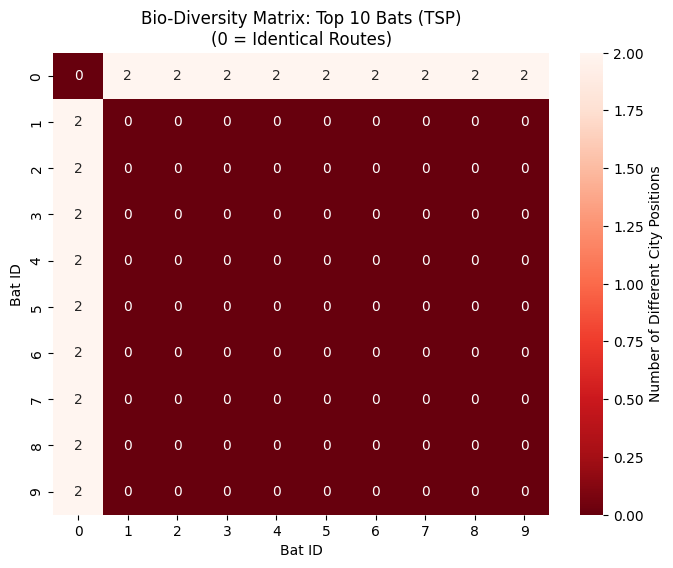

In [7]:
print("Generating Permutation Bio-Diversity Matrix (Standard BA)...")

pop_size_matrix = 20
positions_matrix = np.array([np.random.permutation(NUM_CITIES) for _ in range(pop_size_matrix)])
best_pos = positions_matrix[0].copy()

for gen in range(50):
    for i in range(pop_size_matrix):
        swaps = get_swap_sequence(positions_matrix[i], best_pos)
        positions_matrix[i] = apply_swaps(positions_matrix[i], swaps, random.uniform(0, 1.0))
        
        if fitness_tsp(positions_matrix[i]) < fitness_tsp(best_pos):
            best_pos = positions_matrix[i].copy()

fitness_scores = [fitness_tsp(p) for p in positions_matrix]
top_10_indices = np.argsort(fitness_scores)[:10]
top_10_bats = positions_matrix[top_10_indices]

# In permutation spaces, Hamming distance measures exact positional alignment
dist_matrix = squareform(pdist(top_10_bats, metric='hamming')) * NUM_CITIES

plt.figure(figsize=(8, 6))
sns.heatmap(dist_matrix, annot=True, cmap="Reds_r", cbar_kws={'label': 'Number of Different City Positions'})
plt.title("Bio-Diversity Matrix: Top 10 Bats (TSP)\n(0 = Identical Routes)")
plt.xlabel("Bat ID")
plt.ylabel("Bat ID")
plt.show()

In [8]:
print("==================================================")
print("   SCALABILITY STRESS TEST (V2: TUNED + SMART)    ")
print("==================================================")

city_sizes = [10, 20, 30, 40, 50]
runs_per_size = 5 # Reduced slightly because TSP distance matrices are heavier
results = []

for size in city_sizes:
    print(f"\n[>>>] Stressing {size}-City Route (Constrained Population: 30)...")
    
    global DIST_MATRIX, NUM_CITIES
    original_matrix, original_num = DIST_MATRIX.copy(), NUM_CITIES
    
    NUM_CITIES = size
    temp_coords = np.random.rand(size, 2) * 100
    DIST_MATRIX = squareform(pdist(temp_coords, metric='euclidean'))
    
    avg_dists = []
    start_time = time.time()
    
    for run in range(runs_per_size):
        test_pop = smart_initialization_tsp(pop_size=30, num_cities=size)
        
        best_val, _, _, _, _ = enhanced_bat_algorithm(
            n_cities=size, pop_size=30, max_gens=100, 
            a_init=TUNED_A_INIT, r_init=TUNED_R_INIT, 
            f_max=TUNED_F_MAX, alpha=TUNED_ALPHA, gamma=TUNED_GAMMA, 
            init_pop=test_pop
        )
        
        avg_dists.append(best_val)
        print(f"      Run {run+1}/5: [COMPLETE] Best Distance Found: {best_val:.2f}")
            
    exec_time = time.time() - start_time
    mean_dist = np.mean(avg_dists)
    
    results.append([f"{size} Cities", f"{mean_dist:.2f}", f"{exec_time:.2f}s"])
    
    DIST_MATRIX, NUM_CITIES = original_matrix, original_num

print("\n--- FINAL SCALABILITY METRICS ---")
header = f"| {'Domain Complexity':<20} | {'Avg Best Distance':<18} | {'Total Exec Time':<15} |"
print("-" * len(header))
print(header)
print("-" * len(header))
for row in results:
    print(f"| {row[0]:<20} | {row[1]:<18} | {row[2]:<15} |")
print("-" * len(header))

   SCALABILITY STRESS TEST (V2: TUNED + SMART)    

[>>>] Stressing 10-City Route (Constrained Population: 30)...
      Run 1/5: [COMPLETE] Best Distance Found: 262.05
      Run 2/5: [COMPLETE] Best Distance Found: 262.05
      Run 3/5: [COMPLETE] Best Distance Found: 258.28
      Run 4/5: [COMPLETE] Best Distance Found: 262.05
      Run 5/5: [COMPLETE] Best Distance Found: 262.05

[>>>] Stressing 20-City Route (Constrained Population: 30)...
      Run 1/5: [COMPLETE] Best Distance Found: 448.61
      Run 2/5: [COMPLETE] Best Distance Found: 457.79
      Run 3/5: [COMPLETE] Best Distance Found: 448.61
      Run 4/5: [COMPLETE] Best Distance Found: 433.06
      Run 5/5: [COMPLETE] Best Distance Found: 457.79

[>>>] Stressing 30-City Route (Constrained Population: 30)...
      Run 1/5: [COMPLETE] Best Distance Found: 497.22
      Run 2/5: [COMPLETE] Best Distance Found: 500.33
      Run 3/5: [COMPLETE] Best Distance Found: 476.36
      Run 4/5: [COMPLETE] Best Distance Found: 517.73
    

To do : why did this work, what have i done that made it work, more details and documentation
